In [1]:
!pip install faiss-cpu -q

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
from pathlib import Path
from tqdm import tqdm
import faiss
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 77.9 MB/s eta 0:00:00:00:0100:01
Device: cuda


In [2]:
IMAGE_DIR = '/kaggle/input/datasets/samanvithkashyap/nga-portraits/nga_paintings'
CSV_PATH  = '/kaggle/input/datasets/samanvithkashyap/objects/objects.csv'
EMB_PATH  = '/kaggle/working/embeddings.npy'
IDS_PATH  = '/kaggle/working/image_ids.npy'

In [3]:
df = pd.read_csv(CSV_PATH, low_memory=False)
paintings = df[df['classification'] == 'Painting'].copy()

available_ids = set(int(Path(f).stem) for f in os.listdir(IMAGE_DIR) if f.endswith('.jpg'))
paintings = paintings[paintings['objectid'].isin(available_ids)].reset_index(drop=True)

print(f"Paintings with images on disk: {len(paintings)}")
print(paintings[['objectid', 'title', 'attribution']].head())

Paintings with images on disk: 4037
   objectid                                              title  \
0         0                                  Saint James Major   
1         1              Saint Paul and a Group of Worshippers   
2         2  Saint Andrew and Saint Benedict with the Archa...   
3         3  Madonna and Child Enthroned with Twelve Angels...   
4         4  Saint Bernard and Saint Catherine of Alexandri...   

         attribution  
0  Grifo di Tancredi  
1     Bernardo Daddi  
2       Agnolo Gaddi  
3       Agnolo Gaddi  
4       Agnolo Gaddi  


In [4]:
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
model.eval()
model.to(DEVICE)
print("DINOv2 ViT-B/14 loaded")

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:06<00:00, 52.3MB/s] 


DINOv2 ViT-B/14 loaded


In [5]:
transform = transforms.Compose([
    transforms.Resize((518, 518)),  # native DINOv2 resolution
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
def extract_embeddings(image_dir, object_ids, batch_size=32):
    embeddings = []
    valid_ids = []
    
    paths = []
    for oid in object_ids:
        p = os.path.join(image_dir, f"{oid}.jpg")
        if os.path.exists(p):
            paths.append((oid, p))
    
    for i in tqdm(range(0, len(paths), batch_size)):
        batch_paths = paths[i:i+batch_size]
        batch_tensors = []
        batch_ids = []
        
        for oid, path in batch_paths:
            try:
                img = Image.open(path).convert('RGB')
                tensor = transform(img)
                batch_tensors.append(tensor)
                batch_ids.append(oid)
            except Exception as e:
                print(f"Failed to load {path}: {e}")
                continue
        
        if not batch_tensors:
            continue
            
        batch = torch.stack(batch_tensors).to(DEVICE)
        
        with torch.no_grad():
            feats = model(batch)  # (B, 768)
        
        embeddings.append(feats.cpu().numpy())
        valid_ids.extend(batch_ids)
    
    return np.vstack(embeddings), np.array(valid_ids)

embeddings, image_ids = extract_embeddings(IMAGE_DIR, paintings['objectid'].tolist())
print(f"Embeddings shape: {embeddings.shape}")  # (N, 768)

100%|██████████| 127/127 [08:28<00:00,  4.00s/it]

Embeddings shape: (4037, 768)


In [7]:
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings_norm = embeddings / norms

np.save(EMB_PATH, embeddings_norm)
np.save(IDS_PATH, image_ids)
print("Saved embeddings and IDs")

Saved embeddings and IDs


In [8]:
dim = embeddings_norm.shape[1]  # 768

index = faiss.IndexFlatIP(dim)
index.add(embeddings_norm.astype(np.float32))
print(f"FAISS index built. Total vectors: {index.ntotal}")

FAISS index built. Total vectors: 4037


In [9]:
def query(image_path, top_k=5):
    img = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        emb = model(tensor).cpu().numpy()
    
    emb = emb / np.linalg.norm(emb)
    
    distances, indices = index.search(emb.astype(np.float32), top_k + 1)
    
    results = []
    for dist, idx in zip(distances[0][1:], indices[0][1:]):
        oid = image_ids[idx]
        meta = paintings[paintings['objectid'] == oid].iloc[0]
        results.append({
            'objectid': oid,
            'title': meta['title'],
            'artist': meta['attribution'],
            'similarity': dist
        })
    
    return results

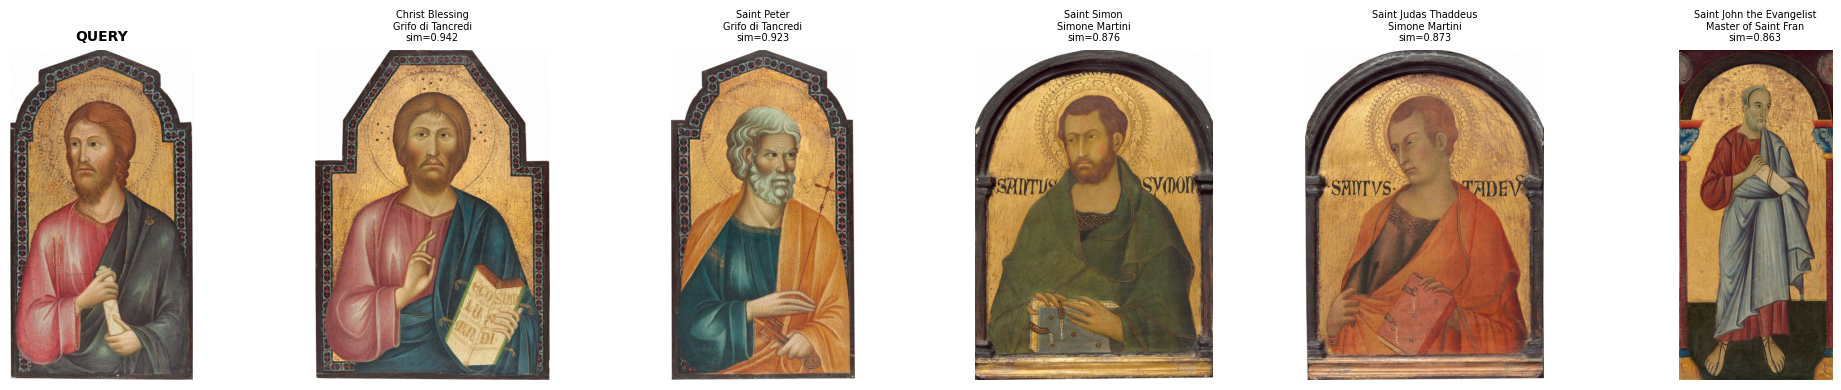

In [10]:
def visualize_query(image_path, top_k=5):
    results = query(image_path, top_k)
    
    fig, axes = plt.subplots(1, top_k + 1, figsize=(20, 4))
    
    axes[0].imshow(Image.open(image_path))
    axes[0].set_title("QUERY", fontsize=10, fontweight='bold')
    axes[0].axis('off')
    
    for i, res in enumerate(results):
        img_path = os.path.join(IMAGE_DIR, f"{res['objectid']}.jpg")
        axes[i+1].imshow(Image.open(img_path))
        axes[i+1].set_title(
            f"{res['title'][:25]}\n{res['artist'][:20]}\nsim={res['similarity']:.3f}",
            fontsize=7
        )
        axes[i+1].axis('off')
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/query_result.png', dpi=150, bbox_inches='tight')
    plt.show()

# Test with a random painting
test_image = os.path.join(IMAGE_DIR, f"{paintings['objectid'].iloc[0]}.jpg")
visualize_query(test_image)

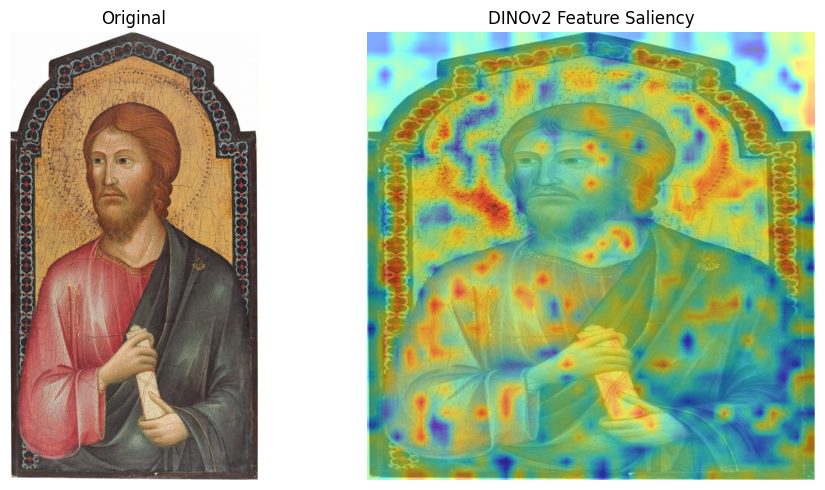

In [16]:
def visualize_attention(image_path):
    img = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(DEVICE)

    features = {}

    def hook_fn(module, input, output):
        # input[0] shape: (1, num_tokens, 768)
        features['tokens'] = input[0]

    hook = model.blocks[-1].attn.proj.register_forward_hook(hook_fn)

    with torch.no_grad():
        model(tensor)

    hook.remove()

    tokens = features['tokens'][0]  # (num_tokens, 768)
    
    # Patch tokens only (skip CLS at index 0)
    patch_tokens = tokens[1:]  # (num_patches, 768)
    
    # Use L2 norm of each patch token as saliency
    saliency = patch_tokens.norm(dim=-1).cpu().numpy()  # (num_patches,)
    
    grid_size = int(saliency.shape[0] ** 0.5)
    saliency_map = saliency.reshape(grid_size, grid_size)

    import torch.nn.functional as F
    sal_tensor = torch.tensor(saliency_map).unsqueeze(0).unsqueeze(0)
    sal_resized = F.interpolate(sal_tensor, size=(518, 518), mode='bilinear').squeeze().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis('off')

    axes[1].imshow(img.resize((518, 518)))
    axes[1].imshow(sal_resized, alpha=0.5, cmap='jet')
    axes[1].set_title("DINOv2 Feature Saliency")
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig('/kaggle/working/attention_map.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_attention(test_image)

In [15]:
print(model.blocks[-1].attn)

MemEffAttention(
  (qkv): Linear(in_features=768, out_features=2304, bias=True)
  (proj): Linear(in_features=768, out_features=768, bias=True)
  (proj_drop): Dropout(p=0.0, inplace=False)
)


2026-03-19 12:03:50.148155: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773921830.571717      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773921830.698686      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773921831.806610      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773921831.806639      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773921831.806641      55 computation_placer.cc:177] computation placer alr

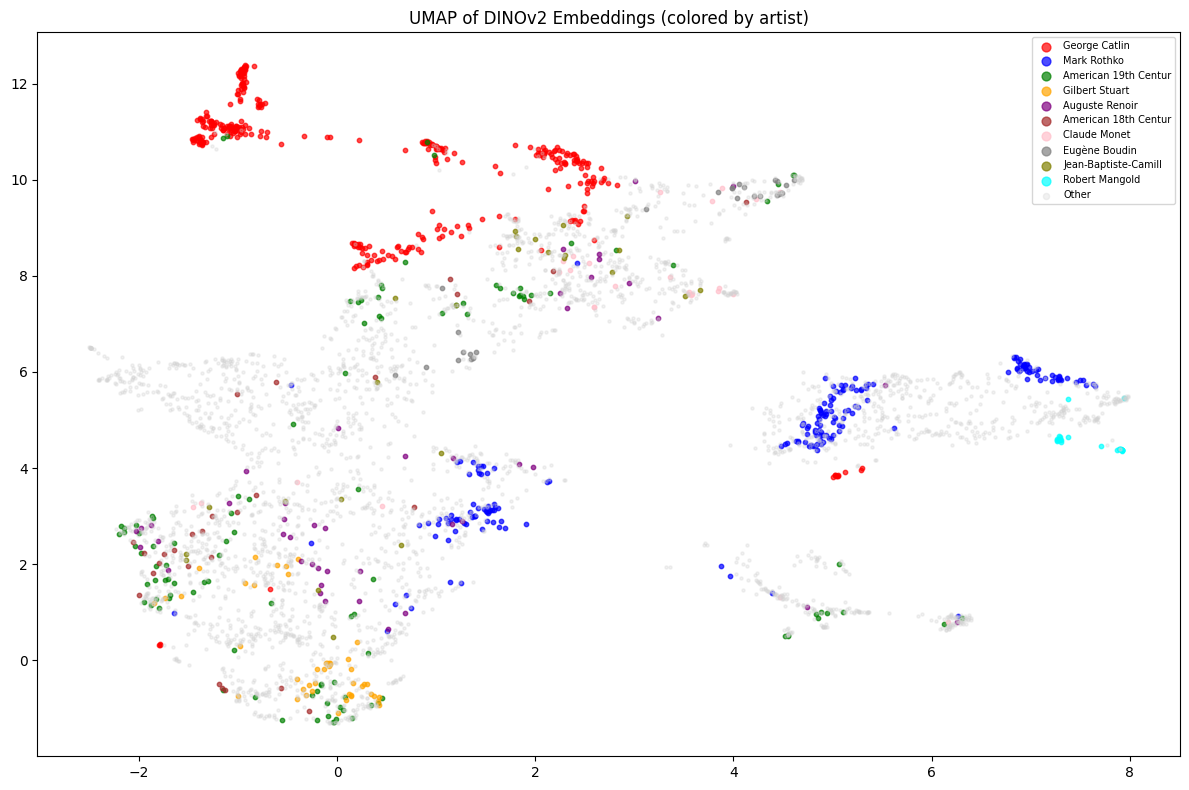

In [17]:
!pip install umap-learn -q

import umap

# Get artist labels for coloring
id_to_artist = dict(zip(paintings['objectid'], paintings['attribution']))
labels = [id_to_artist.get(oid, 'Unknown') for oid in image_ids]

# Top 10 artists only for clean visualization
from collections import Counter
top_artists = [a for a, _ in Counter(labels).most_common(10)]
colors = ['red','blue','green','orange','purple','brown','pink','gray','olive','cyan']
artist_color = {a: c for a, c in zip(top_artists, colors)}

# UMAP reduction
reducer = umap.UMAP(n_components=2, random_state=42)
emb_2d = reducer.fit_transform(embeddings_norm)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
for artist, color in artist_color.items():
    mask = [l == artist for l in labels]
    ax.scatter(
        emb_2d[mask, 0], emb_2d[mask, 1],
        c=color, label=artist[:20], s=10, alpha=0.7
    )

# Plot unknown/other in gray
other_mask = [l not in top_artists for l in labels]
ax.scatter(emb_2d[other_mask, 0], emb_2d[other_mask, 1],
           c='lightgray', s=5, alpha=0.3, label='Other')

ax.legend(fontsize=7, markerscale=2)
ax.set_title("UMAP of DINOv2 Embeddings (colored by artist)")
plt.tight_layout()
plt.savefig('/kaggle/working/umap.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
def evaluate_recall_at_k(k_values=[1, 5, 10]):
    id_to_artist = dict(zip(paintings['objectid'], paintings['attribution']))
    recall_at_k = {k: [] for k in k_values}
    
    sample = paintings.sample(min(200, len(paintings)), random_state=42)
    
    for _, row in tqdm(sample.iterrows(), total=len(sample)):
        oid = row['objectid']
        artist = row['attribution']
        
        if pd.isna(artist):
            continue
        
        img_path = os.path.join(IMAGE_DIR, f"{oid}.jpg")
        if not os.path.exists(img_path):
            continue
        
        results = query(img_path, top_k=max(k_values))
        retrieved_artists = [r['artist'] for r in results]
        
        for k in k_values:
            hit = any(a == artist for a in retrieved_artists[:k])
            recall_at_k[k].append(float(hit))
    
    print("\n── Recall@K Results ──")
    for k in k_values:
        print(f"R@{k}: {np.mean(recall_at_k[k]):.3f}")

evaluate_recall_at_k()

100%|██████████| 200/200 [00:24<00:00,  8.06it/s]


── Recall@K Results ──
R@1: 0.315
R@5: 0.400
R@10: 0.440
